<a href="https://colab.research.google.com/github/HoniTahina/-arene-des-algos-Tahina-HONI-RIKA/blob/main/Telco_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Phase 0: Récupérer la donnée et l'ouvrir

In [67]:
import pandas as pd
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Forme :", df.shape)
print(df.dtypes)
df.head()

Forme : (7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Phase 1: L'audit qualité

In [68]:
def audit_qualite(df):
    # 1. Dimensions
    print(f"Lignes, Colonnes: ({df.shape[0]}, {df.shape[1]})" )
    print("--------------------------")
    # 2. Types des colonnes
    print(df.dtypes)
    print("--------------------------")
    # 3. Valeurs manquantes
    manquants = df.isnull().sum()
    manquant_pct = (manquants / len(df) * 100).round(2)

    rapport_missing = pd.DataFrame({
        "Nombre": manquants,
        "Pourcentage (%)": manquant_pct
    }).sort_values(by="Nombre", ascending=False)
    manquants = manquants[manquants > 0]

    if len(manquants) == 0:
        print("Aucune valeur manquante")
    else:
      print(rapport_missing)
    print("--------------------------")

    # 4. Répartition de la cible
    effectifs = df["Churn"].value_counts()
    pourcentages = df["Churn"].value_counts(normalize=True) * 100
    ratio = effectifs / len(df)
    repartition = pd.DataFrame({
        "Nombre": effectifs,
        "Pourcentage (%)": pourcentages.round(2)
    })
    if ratio.max() > 0.7:
      print("Classe déséquilibrée")
    else:
      print("Classe équilibrée")
    print(repartition)

In [69]:
audit_qualite(df)

Lignes, Colonnes: (7043, 21)
--------------------------
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
--------------------------
Aucune valeur manquante
--------------------------
Classe déséquilibrée
       Nombre  Pourcentage (%)
Churn                         
No       5174            73.46
Yes      1869            26.54


In [64]:
# CAS LIMITE : une seule classe
df_single_class = df[df["Churn"] == "No"]

audit_qualite(df_single_class)

Lignes, Colonnes: (5174, 21)
--------------------------
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object
--------------------------
Aucune valeur manquante
--------------------------
Classe déséquilibrée
       Nombre  Pourcentage (%)
Churn                         
No       5174            100.0


Résultat :

le code ne plante pas
Mais on obtiens :
No: 100%
Yes: n’existe pas
>perte d’information critique : absence totale d’une classe

Phase 2: La colonne piégée (types incohérents et trous cachés)

In [70]:
import numpy as np

def reparer_total_charges(df):
    df = df.copy()

    col = "TotalCharges"

    # 1. détecter valeurs problématiques AVANT conversion
    raw = df[col].astype(str)

    espaces = (raw.str.strip() == "").sum()

    # détection virgule (cas adversarial)
    virgules = raw.str.contains(",", na=False).sum()

    print(f"Valeurs vides cachées (' ') : {espaces}")
    print(f"Valeurs avec virgule suspecte : {virgules}")

    # 2. conversion safe
    df[col] = pd.to_numeric(df[col], errors="coerce")

    # 3. NaN révélés
    nan_count = df[col].isna().sum()
    print(f"Total NaN après conversion : {nan_count}")

    # 4. traitement (choix justifié)
    mediane = df[col].median()

    df[col] = df[col].fillna(mediane)

    print(f"NaN restants après imputation : {df[col].isna().sum()}")

    return df

In [71]:
df = reparer_total_charges(df)
audit_qualite(df)

Valeurs vides cachées (' ') : 11
Valeurs avec virgule suspecte : 0
Total NaN après conversion : 11
NaN restants après imputation : 0
Lignes, Colonnes: (7043, 21)
--------------------------
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object
--------------------------
Aucune valeur manquante
--------------------------
Classe déséquilibrée
       Nombre  Pourcentage (%)
Churn                         
No       5174            73.46
Yes      1869    

Phase 3:Encoderles catégorielles

In [72]:
def encoder_features(df):
    df = df.copy()

    # 1. Identifier les colonnes catégorielles
    cat_cols = df.select_dtypes(include=["object"]).columns

    print(f"Colonnes catégorielles détectées : {list(cat_cols)}")

    # 2. Supprimer l'identifiant
    if "customerID" in df.columns:
        df = df.drop(columns=["customerID"])
        print("customerID supprimé (identifiant non informatif)")

    # 3. Encodage Yes/No → 0/1
    binary_map = {"Yes": 1, "No": 0}

    for col in df.columns:
        if df[col].dtype == "object":

            # cas binaire Yes/No
            unique_vals = df[col].dropna().unique()

            if set(unique_vals).issubset({"Yes", "No"}):
                df[col] = df[col].map(binary_map)

    # 4. One-Hot Encoding pour les autres catégorielles
    cat_cols = df.select_dtypes(include=["object"]).columns

    df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

    print(f"Shape après encodage : {df.shape}")

    # vérification
    print("\nTypes après encodage :")
    print(df.dtypes.value_counts())

    return df

In [73]:
df = encoder_features(df)

Colonnes catégorielles détectées : ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
customerID supprimé (identifiant non informatif)
Shape après encodage : (7043, 42)

Types après encodage :
bool       33
int64       7
float64     2
Name: count, dtype: int64


Phase 4: Traiter les valeurs aberrantes

In [74]:
def detecter_outliers_iqr(df, colonne):
    serie = df[colonne].dropna()

    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)

    IQR = Q3 - Q1

    borne_basse = Q1 - 1.5 * IQR
    borne_haute = Q3 + 1.5 * IQR

    outliers = serie[(serie < borne_basse) | (serie > borne_haute)]

    print(f"\nColonne : {colonne}")
    print(f"Borne basse : {borne_basse:.2f}")
    print(f"Borne haute : {borne_haute:.2f}")
    print(f"Nombre d'outliers : {len(outliers)}")

    return borne_basse, borne_haute, outliers

In [75]:
import matplotlib.pyplot as plt

def boxplot_col(df, colonne):
    plt.figure()
    df.boxplot(column=colonne)
    plt.title(f"Boxplot - {colonne}")
    plt.show()


Colonne : tenure
Borne basse : -60.00
Borne haute : 124.00
Nombre d'outliers : 0


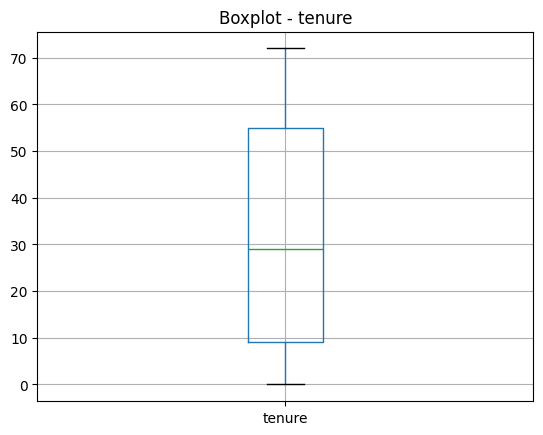


Colonne : MonthlyCharges
Borne basse : -46.02
Borne haute : 171.38
Nombre d'outliers : 0


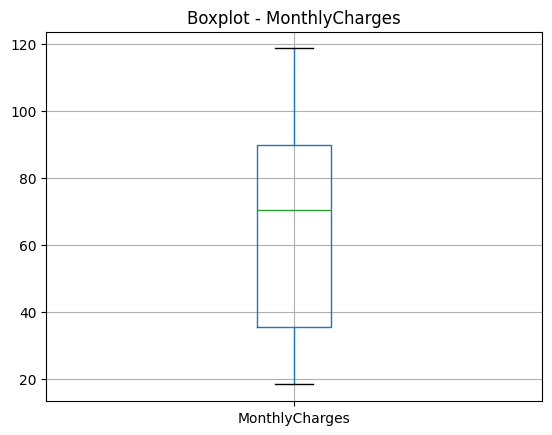


Colonne : TotalCharges
Borne basse : -4674.34
Borne haute : 8863.16
Nombre d'outliers : 0


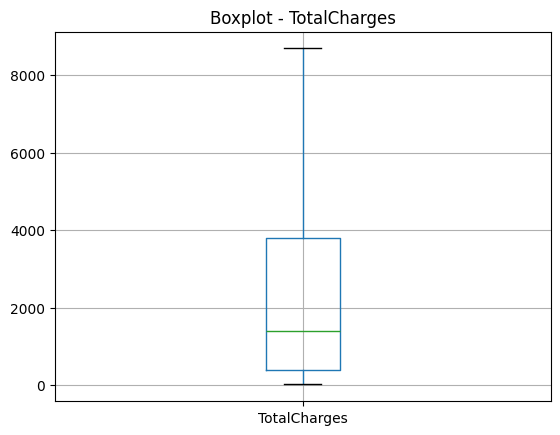

In [76]:
colonnes = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in colonnes:
    detecter_outliers_iqr(df, col)
    boxplot_col(df, col)